Підготовка даних + Перевірка нормальності

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro, mannwhitneyu, spearmanr, chi2_contingency, t

# завантаження даних
df = pd.read_excel('/content/data_fin.xlsx')
data = df.copy()

# додаткові індикатори
data['no_orders_flag'] = (data['orders_cnt_last_3m'] == 0).astype(int)
data['no_recent_orders_flag'] = (data['days_since_last_order'] == 2000).astype(int)

# заміна технічних значень
data['avg_days_between_orders'] = data['avg_days_between_orders'].replace(999, 0)
data['days_since_last_order'] = data['days_since_last_order'].replace(2000, 0)

# підпис гендеру
data['gender_label'] = data['Contractor_Gender'].map({
    0: 'Жінки',
    1: 'Чоловіки'
})

data.head()

,user_id,Contract_dateStart,Contractor_Gender,Age_Simple,bnpl_limit,orders_cnt_last_3m,total_spent_last_3m,avg_check_last_3m,max_check_last_3m,expensive_orders_share,...,had_bnpl_before,bnpl_orders_cnt_last_3m,bnpl_share,utilization,last_order_amount,last_order_was_bnpl,used_bnpl,no_orders_flag,no_recent_orders_flag,gender_label
0,13246376,2026-02-18 00:00:00.000,0,62,30000,0,0,0.000000,0,0.000000,...,0,0,0.000,0.0000,0,0,0,1,1,Жінки
1,13248262,2026-02-24 00:00:00.000,0,42,30000,1,3399,3399.000000,3399,1.000000,...,1,1,1.000,0.1133,3399,1,0,0,0,Жінки
2,13248353,2026-02-12 00:00:00.000,1,41,5000,8,7787,973.375000,4699,0.125000,...,1,7,0.875,1.3994,376,1,1,0,0,Чоловіки
3,13249627,2026-01-11 00:00:00.000,0,39,30000,6,4850,808.333333,1129,0.166667,...,0,0,0.000,0.0000,409,0,0,0,0,Жінки
4,13250393,2026-01-11 00:00:00.000,1,32,10000,0,0,0.000000,0,0.000000,...,0,0,0.000,0.0000,0,0,0,1,1,Чоловіки


In [29]:
normality_vars = ['orders_cnt_last_3m', 'total_spent_last_3m', 'Age_Simple']

normality_results = []

for col in normality_vars:
    sample = data[col].dropna()

    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)

    stat, p_value = shapiro(sample)

    normality_results.append({
        'variable': col,
        'test': 'Shapiro-Wilk',
        'statistic': round(stat, 4),
        'p_value': f"{p_value:.4e}",
        'decision': 'H0 відхиляємо' if p_value < 0.05 else 'Немає підстав відхиляти H0'
    })

normality_table = pd.DataFrame(normality_results)

print("=== Перевірка нормальності ===")
normality_table

=== Перевірка нормальності ===


,variable,test,statistic,p_value,decision
0,orders_cnt_last_3m,Shapiro-Wilk,0.4631,1.0762e-81,H0 відхиляємо
1,total_spent_last_3m,Shapiro-Wilk,0.4395,1.2291e-82,H0 відхиляємо
2,Age_Simple,Shapiro-Wilk,0.9838,1.7105e-23,H0 відхиляємо


Описова статистика по гендеру

In [30]:
gender_summary = data.groupby('gender_label')[['orders_cnt_last_3m', 'total_spent_last_3m']].agg(['count', 'mean', 'median'])

print("=== Описова статистика за гендером ===")
gender_summary

=== Описова статистика за гендером ===


orders_cnt_last_3m                  total_spent_last_3m  \
                          count      mean median               count   
gender_label                                                           
Жінки                     23917  6.275369    1.0               23917   
Чоловіки                   6667  2.934153    0.0                6667   

                                   
                     mean  median  
gender_label                       
Жінки         5719.319898  1091.0  
Чоловіки      3706.174141     0.0

Чатка нульових значень

In [31]:
zero_check = data.groupby('gender_label').agg(
    orders_zero_share=('orders_cnt_last_3m', lambda x: (x == 0).mean()),
    spent_zero_share=('total_spent_last_3m', lambda x: (x == 0).mean()),
    orders_nonzero_share=('orders_cnt_last_3m', lambda x: (x > 0).mean()),
    spent_nonzero_share=('total_spent_last_3m', lambda x: (x > 0).mean())
)

print("=== Частка нульових і ненульових значень ===")
zero_check

=== Частка нульових і ненульових значень ===


,orders_zero_share,spent_zero_share,orders_nonzero_share,spent_nonzero_share
gender_label,,,,
Жінки,0.414266,0.414266,0.585734,0.585734
Чоловіки,0.527074,0.527074,0.472926,0.472926


Формулювання і перевірка гіпотез

Гіпотеза 1
H₀: розподіл orders_cnt_last_3m у жінок і чоловіків однаковий
H₁: розподіли orders_cnt_last_3m у жінок і чоловіків відрізняються
Гіпотеза 2
H₀: розподіл total_spent_last_3m у жінок і чоловіків однаковий
H₁: розподіли total_spent_last_3m у жінок і чоловіків відрізняються
Гіпотеза 3
H₀: had_bnpl_before не пов’язаний із used_bnpl
H₁: had_bnpl_before пов’язаний із used_bnpl
Гіпотеза 4
H₀: вік не пов’язаний із used_bnpl
H₁: вік пов’язаний із used_bnpl

In [37]:
results = []

female_orders = data.loc[data['Contractor_Gender'] == 0, 'orders_cnt_last_3m']
male_orders = data.loc[data['Contractor_Gender'] == 1, 'orders_cnt_last_3m']

female_spent = data.loc[data['Contractor_Gender'] == 0, 'total_spent_last_3m']
male_spent = data.loc[data['Contractor_Gender'] == 1, 'total_spent_last_3m']

female_last_bnpl = data.loc[data['Contractor_Gender'] == 0, 'last_order_was_bnpl']
male_last_bnpl = data.loc[data['Contractor_Gender'] == 1, 'last_order_was_bnpl']

# -----------------------------------------
# Гіпотеза 1: orders_cnt_last_3m
# -----------------------------------------
stat, p_value = mannwhitneyu(female_orders, male_orders, alternative='two-sided')
direction_1 = 'вищі у жінок' if female_orders.median() > male_orders.median() else 'вищі у чоловіків'

results.append({
    'hypothesis': 'Розподіл orders_cnt_last_3m у жінок і чоловіків відрізняється',
    'test': 'Mann–Whitney U',
    'statistic': round(stat, 4),
    'p_value': f"{p_value:.4e}",
    'decision': 'H0 відхиляємо' if p_value < 0.05 else 'Немає підстав відхиляти H0',
    'direction': direction_1 if p_value < 0.05 else 'статистично значущої різниці не виявлено'
})

# -----------------------------------------
# Гіпотеза 2: total_spent_last_3m
# -----------------------------------------
stat, p_value = mannwhitneyu(female_spent, male_spent, alternative='two-sided')
direction_2 = 'вищі у жінок' if female_spent.median() > male_spent.median() else 'вищі у чоловіків'

results.append({
    'hypothesis': 'Розподіл total_spent_last_3m у жінок і чоловіків відрізняється',
    'test': 'Mann–Whitney U',
    'statistic': round(stat, 4),
    'p_value': f"{p_value:.4e}",
    'decision': 'H0 відхиляємо' if p_value < 0.05 else 'Немає підстав відхиляти H0',
    'direction': direction_2 if p_value < 0.05 else 'статистично значущої різниці не виявлено'
})

# -----------------------------------------
# Гіпотеза 3: last_order_was_bnpl і стать
# -----------------------------------------
contingency_table_gender_bnpl = pd.crosstab(data['Contractor_Gender'], data['last_order_was_bnpl'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table_gender_bnpl, correction=False)

results.append({
    'hypothesis': 'last_order_was_bnpl пов’язаний зі статтю клієнта',
    'test': 'Chi-square',
    'statistic': round(chi2, 4),
    'p_value': f"{p_value:.4e}",
    'decision': 'H0 відхиляємо' if p_value < 0.05 else 'Немає підстав відхиляти H0',
    'direction': 'є статистично значущий зв’язок' if p_value < 0.05 else 'зв’язку не виявлено'
})
# -----------------------------------------
# Гіпотеза 4: had_bnpl_before і used_bnpl
# -----------------------------------------
contingency_table = pd.crosstab(data['had_bnpl_before'], data['used_bnpl'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table, correction=False)

results.append({
    'hypothesis': 'had_bnpl_before пов’язаний із used_bnpl',
    'test': 'Chi-square',
    'statistic': round(chi2, 4),
    'p_value': f"{p_value:.4e}",
    'decision': 'H0 відхиляємо' if p_value < 0.05 else 'Немає підстав відхиляти H0',
    'direction': 'є статистично значущий зв’язок' if p_value < 0.05 else 'зв’язку не виявлено'
})

# -----------------------------------------
# Гіпотеза 5: Age_Simple і used_bnpl
# -----------------------------------------
corr, p_value = spearmanr(data['Age_Simple'], data['used_bnpl'])

results.append({
    'hypothesis': 'Age_Simple пов’язаний із used_bnpl',
    'test': 'Spearman correlation',
    'statistic': round(corr, 4),
    'p_value': f"{p_value:.4e}",
    'decision': 'H0 відхиляємо' if p_value < 0.05 else 'Немає підстав відхиляти H0',
    'direction': 'додатний зв’язок' if (p_value < 0.05 and corr > 0) else ('від’ємний зв’язок' if (p_value < 0.05 and corr < 0) else 'зв’язку не виявлено')
})

hypothesis_results = pd.DataFrame(results)

print("=== Результати перевірки статистичних гіпотез ===")
hypothesis_results

=== Результати перевірки статистичних гіпотез ===


,hypothesis,test,statistic,p_value,decision,direction
0,Розподіл orders_cnt_last_3m у жінок і чоловікі...,Mann–Whitney U,9.368820e+07,3.6226e-116,H0 відхиляємо,вищі у жінок
1,Розподіл total_spent_last_3m у жінок і чоловік...,Mann–Whitney U,9.167078e+07,2.2676e-85,H0 відхиляємо,вищі у жінок
2,last_order_was_bnpl пов’язаний зі статтю клієнта,Chi-square,3.075400e+00,7.9486e-02,Немає підстав відхиляти H0,зв’язку не виявлено
3,had_bnpl_before пов’язаний із used_bnpl,Chi-square,2.030154e+03,0.0000e+00,H0 відхиляємо,є статистично значущий зв’язок
4,Age_Simple пов’язаний із used_bnpl,Spearman correlation,1.790000e-02,1.7241e-03,H0 відхиляємо,додатний зв’язок


Звідна табличка

In [33]:
final_hypothesis_table = hypothesis_results.copy()

final_hypothesis_table['conclusion'] = final_hypothesis_table.apply(
    lambda row: (
        f"виявлено статистично значущу різницю; значення {row['direction']}"
        if row['test'] == 'Mann–Whitney U' and row['decision'] == 'H0 відхиляємо' and 'вищі' in row['direction']
        else (
            row['direction'] if row['decision'] == 'H0 відхиляємо'
            else 'статистично значущих підстав не виявлено'
        )
    ),
    axis=1
)

final_hypothesis_table = final_hypothesis_table[['hypothesis', 'test', 'statistic', 'p_value', 'conclusion']]

print("=== Фінальна таблиця для диплома ===")
final_hypothesis_table

=== Фінальна таблиця для диплома ===


,hypothesis,test,statistic,p_value,conclusion
0,Розподіл orders_cnt_last_3m у жінок і чоловікі...,Mann–Whitney U,9.368820e+07,3.6226e-116,виявлено статистично значущу різницю; значення...
1,Розподіл total_spent_last_3m у жінок і чоловік...,Mann–Whitney U,9.167078e+07,2.2676e-85,виявлено статистично значущу різницю; значення...
2,Розподіл last_order_was_bnpl у жінок і чоловік...,Mann–Whitney U,8.058670e+07,7.9491e-02,статистично значущих підстав не виявлено
3,had_bnpl_before пов’язаний із used_bnpl,Chi-square,2.030154e+03,0.0000e+00,є статистично значущий зв’язок
4,Age_Simple пов’язаний із used_bnpl,Spearman correlation,1.790000e-02,1.7241e-03,додатний зв’язок


Boxplot для двох гендерних гіпотез

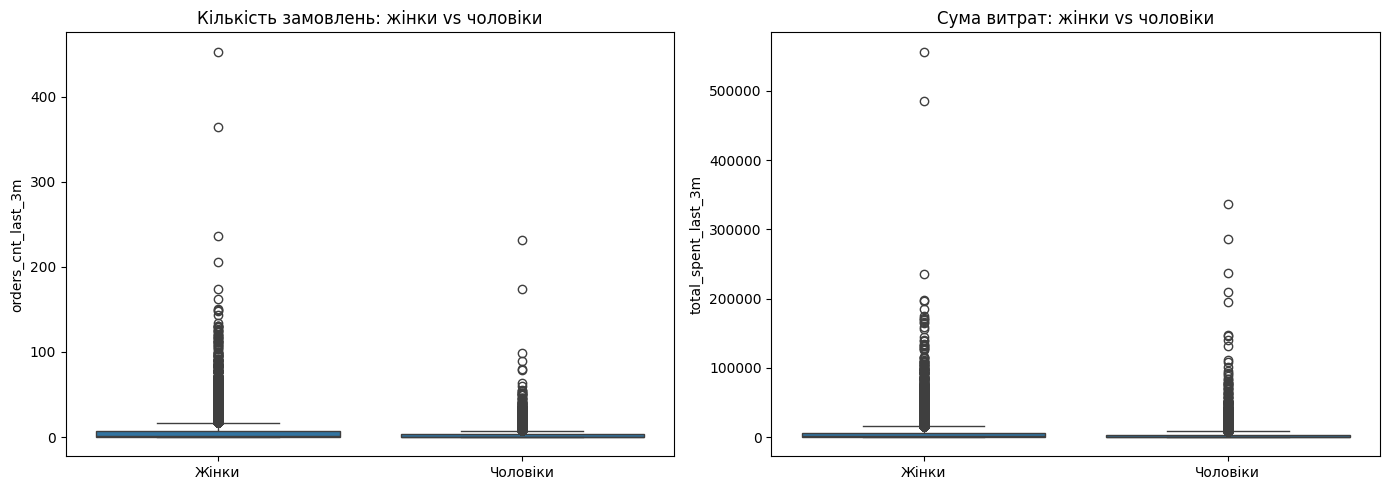

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='gender_label', y='orders_cnt_last_3m', data=data, ax=axes[0])
axes[0].set_title('Кількість замовлень: жінки vs чоловіки')
axes[0].set_xlabel('')
axes[0].set_ylabel('orders_cnt_last_3m')

sns.boxplot(x='gender_label', y='total_spent_last_3m', data=data, ax=axes[1])
axes[1].set_title('Сума витрат: жінки vs чоловіки')
axes[1].set_xlabel('')
axes[1].set_ylabel('total_spent_last_3m')

plt.tight_layout()
plt.show()

Довірчі інтервали для total_spent_last_3m за гендером

In [35]:
def confidence_interval_mean(data_series, confidence=0.95):
    x = data_series.dropna()
    n = len(x)
    mean = x.mean()
    std = x.std(ddof=1)

    t_crit = t.ppf((1 + confidence) / 2, df=n - 1)
    margin = t_crit * std / np.sqrt(n)

    return mean, mean - margin, mean + margin, n

female_mean, female_low, female_high, female_n = confidence_interval_mean(female_spent)
male_mean, male_low, male_high, male_n = confidence_interval_mean(male_spent)

ci_table = pd.DataFrame({
    'group': ['Жінки', 'Чоловіки'],
    'n': [female_n, male_n],
    'mean_total_spent_last_3m': [female_mean, male_mean],
    'ci_lower_95': [female_low, male_low],
    'ci_upper_95': [female_high, male_high]
}).round(2)

print("=== 95% довірчі інтервали для total_spent_last_3m ===")
ci_table

=== 95% довірчі інтервали для total_spent_last_3m ===


,group,n,mean_total_spent_last_3m,ci_lower_95,ci_upper_95
0,Жінки,23917,5719.32,5558.98,5879.66
1,Чоловіки,6667,3706.17,3431.78,3980.57


Графік довірчих інтервалів

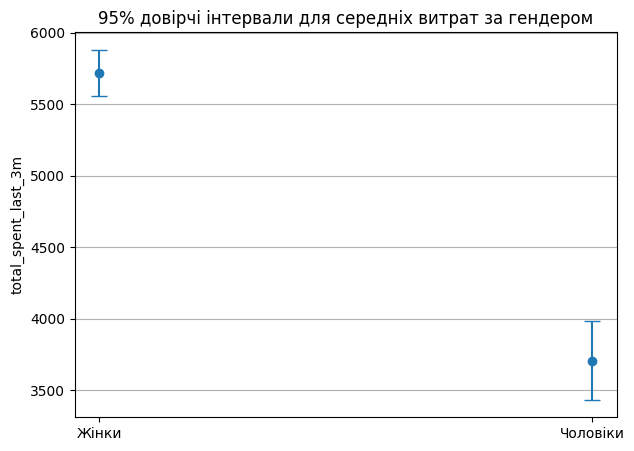

In [36]:
plot_df = ci_table.copy()

means = plot_df['mean_total_spent_last_3m']
lower_err = means - plot_df['ci_lower_95']
upper_err = plot_df['ci_upper_95'] - means

plt.figure(figsize=(7, 5))
plt.errorbar(
    plot_df['group'],
    means,
    yerr=[lower_err, upper_err],
    fmt='o',
    capsize=6
)

plt.title('95% довірчі інтервали для середніх витрат за гендером')
plt.ylabel('total_spent_last_3m')
plt.grid(True, axis='y')
plt.show()